In [44]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.saving import load_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dataset

In [45]:
df = pd.read_csv('C:\\Users\\meerh\\OneDrive\\Documentos\\Projetos\\esp32-fall-detection\\data\\processed\\acc_gyr.csv')
df.shape

(96800, 7)

In [46]:
SEED = 42
MODELS_BASE_PATH = 'C:\\Users\\meerh\\OneDrive\\Documentos\\Projetos\\esp32-fall-detection\\models\\'

In [47]:
X = df.drop('label', axis=1)
y = df['label']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=SEED, stratify=y_test)

X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape

((67760, 6), (67760,), (14520, 6), (14520,), (14520, 6), (14520,))

# Avaliação dos Modelos

In [49]:
model_1 = load_model(MODELS_BASE_PATH + 'best_model_exp1.keras')
model_2 = load_model(MODELS_BASE_PATH + 'best_model_exp2.keras')
model_3 = load_model(MODELS_BASE_PATH + 'best_model_exp3.keras')

model_path = 'C:\\Users\\meerh\\Documents\\esp32-fall-detection\\models\\model_quantized.tflite'
interpreter = tf.lite.Interpreter(model_path=model_path)
interpreter.allocate_tensors()

c:\Users\meerh\Documents\esp32-fall-detection\venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## Modelo 1

In [50]:
model_1_results = model_1.evaluate(X_test, y_test)
model_1_results

454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7953 - f1_score: 0.4487 - loss: 0.0142 - precision: 0.6185 - recall: 0.7631


[0.014248045161366463,
 0.7953168153762817,
 0.6184870600700378,
 0.7630952596664429,
 array([0.4487179], dtype=float32)]

## Modelo 2

In [51]:
model_2_results = model_2.evaluate(X_test, y_test)
model_2_results

454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7921 - f1_score: 0.4487 - loss: 0.0147 - precision: 0.6150 - recall: 0.7517


[0.014738666824996471,
 0.7920798659324646,
 0.6150399446487427,
 0.7516666650772095,
 array([0.4487179], dtype=float32)]

## Modelo 3

In [52]:
model_3_results = model_3.evaluate(X_test, y_test)
model_3_results

454/454 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7795 - f1_score: 0.4487 - loss: 0.0158 - precision: 0.5949 - recall: 0.7457


[0.0158045943826437,
 0.7795454263687134,
 0.5948718190193176,
 0.7457143068313599,
 array([0.4487179], dtype=float32)]

## Modelo 1 Quantizado

In [53]:
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

input_scale, input_zero = input_details["quantization"]
output_scale, output_zero = output_details["quantization"]

previsoes_tflite = []

# Loop de inferência no X_test
for i in range(len(X_test)):
    # Pega uma amostra e formata para (1, 6)
    amostra = np.expand_dims(X_test.iloc[i], axis=0).astype(np.float32)
    
    # Quantiza a entrada (Float -> INT8)
    amostra_quant = (amostra / input_scale) + input_zero
    amostra_quant = amostra_quant.astype(np.int8)
    
    # Executa a IA
    interpreter.set_tensor(input_details['index'], amostra_quant)
    interpreter.invoke()
    
    # Extrai e desquantiza a saída (INT8 -> Float)
    saida_bruta = interpreter.get_tensor(output_details['index'])[0][0]
    saida_float = (saida_bruta.astype(np.float32) - output_zero) * output_scale
    
    # Lógica Sigmoid: Se a probabilidade for >= 50%, é Queda (1)
    classe_predita = 1 if saida_float >= 0.5 else 0
    previsoes_tflite.append(classe_predita)


# =====================================================================
# 5. MÉTRICAS FINAIS
# =====================================================================
# Comparando as previsões do TFLite diretamente com o seu y_test
acc_quantized_model = accuracy_score(y_test, previsoes_tflite)
prec_quantized_model = precision_score(y_test, previsoes_tflite, average='weighted', zero_division=0)
rec_quantized_model = recall_score(y_test, previsoes_tflite, average='weighted', zero_division=0)
f1_quantized_model = f1_score(y_test, previsoes_tflite, average='weighted', zero_division=0)

quantized_model_results = [acc_quantized_model, prec_quantized_model, rec_quantized_model, f1_quantized_model]

print("\n=== Desempenho do Modelo TFLite (INT8) ===")
print(f"Acurácia:  {acc_quantized_model * 100:.2f}%")
print(f"Precisão:  {prec_quantized_model * 100:.2f}%")
print(f"Recall:    {rec_quantized_model * 100:.2f}%")
print(f"F1-Score:  {f1_quantized_model * 100:.2f}%")
print("==========================================")


=== Desempenho do Modelo TFLite (INT8) ===
Acurácia:  75.19%
Precisão:  81.08%
Recall:    75.19%
F1-Score:  67.82%


## Comparativo de Resultados

In [ ]:
results = model_1_results[1:4]
results.extend([model_1_results[-1].item()])
model_1_results = results

results = model_2_results[1:4]
results.extend([model_2_results[-1].item()])
model_2_results = results

results = model_3_results[1:4]
results.extend([model_3_results[-1].item()])
model_3_results = results

resultados = {
    "Model 1": model_1_results,
    "Model 2": model_2_results,
    "Model 3": model_3_results,
    "Quantized Model 1": quantized_model_results
}
resultados

{'Model 1': [0.7953168153762817,
  0.6184870600700378,
  0.7630952596664429,
  0.4487178921699524],
 'Model 2': [0.7920798659324646,
  0.6150399446487427,
  0.7516666650772095,
  0.4487178921699524],
 'Model 3': [0.7795454263687134,
  0.5948718190193176,
  0.7457143068313599,
  0.4487178921699524],
 'Quantized Model': [0.7519283746556474,
  0.8108268734738472,
  0.7519283746556474,
  0.6782170650519631]}

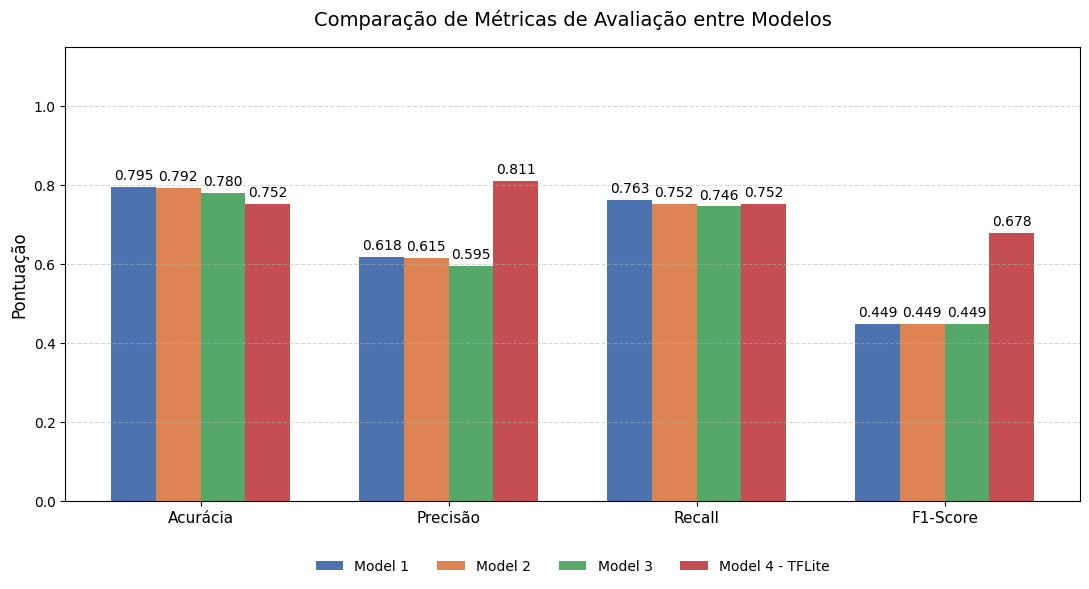

In [55]:
def plot_comparacao_modelos(resultados_modelos):
    metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
    nomes_modelos = list(resultados_modelos.keys())

    if len(nomes_modelos) != 4:
        raise ValueError('O dicionário deve conter exatamente 4 modelos.')

    cores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
    x = np.arange(len(metricas))
    largura = 0.18

    fig, ax = plt.subplots(figsize=(11, 6))

    for indice, nome_modelo in enumerate(nomes_modelos):
        valores = resultados_modelos[nome_modelo]
        deslocamento = (indice - (len(nomes_modelos) - 1) / 2) * largura
        barras = ax.bar(x + deslocamento, valores, largura, label=nome_modelo, color=cores[indice])

        for barra in barras:
            altura = barra.get_height()
            ax.annotate(
                f'{altura:.3f}',
                xy=(barra.get_x() + barra.get_width() / 2, altura),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=10,
            )

    ax.set_ylabel('Pontuação', fontsize=12)
    ax.set_title('Comparação de Métricas de Avaliação entre Modelos', fontsize=14, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(metricas, fontsize=11)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False)
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


resultados_4_modelos = {
    'Model 1': resultados['Model 1'],
    'Model 2': resultados['Model 2'],
    'Model 3': resultados['Model 3'],
    'Model 4 - TFLite': quantized_model_results,
}

resultados_4_modelos

plot_comparacao_modelos(resultados_4_modelos)

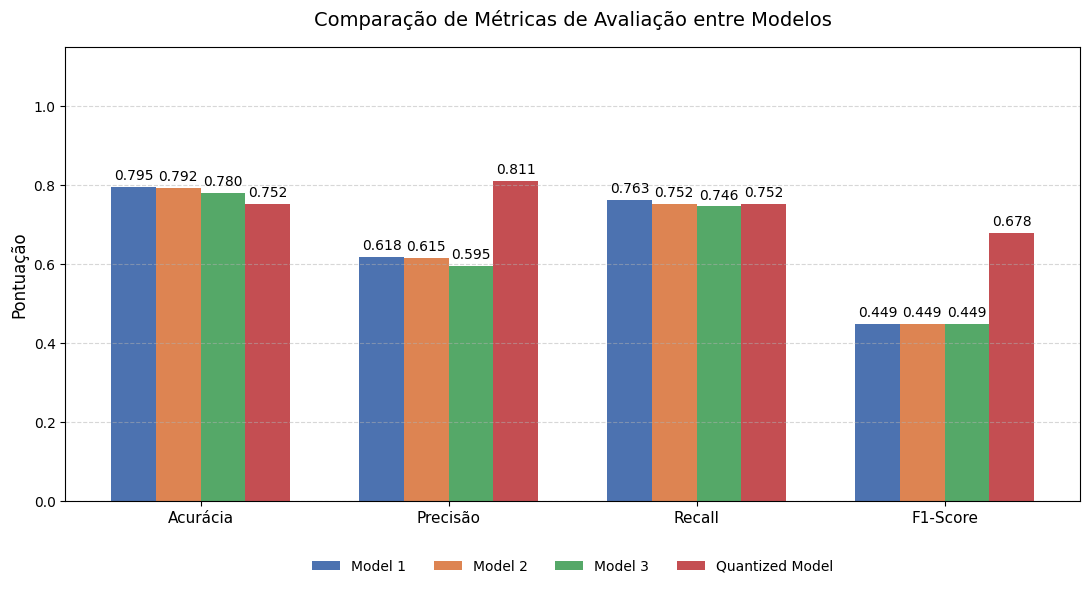

In [56]:
plot_comparacao_modelos(resultados)